# Índice

- [Layout completo](#layout-completo)
- [Componentes](#componentes)
  - [MMI 3x3](#mmi-3x3)
  - [Espiral](#espiral)
  - [Wavelength tracker](#wavelength_tracker)
  - [Estructuras de test](#estructuras-de-test)



In [1]:
import gdsfactory as gf
from upvfab.sin300.cband import PDK, cells
from functools import partial

PDK.activate()

## LAYOUT COMPLETO

<div align="justify">

El layout completo del chip se divide en tres sectores: top, middle y bottom. En los tres sectores se incluye el diseño del wavelength tracker, junto con las estructuras de test necesarias para caracterizar su funcionamiento.

En los sectores top y bottom, el circuito se ha diseñado con grating couplers para permitir la caracterización vertical. La diferencia entre ambos es que, en el sector bottom, se ha aumentado en 3 µm la longitud de los MMI respecto a la longitud obtenida en la fase de diseño.

Por otro lado, el sector middle se ha diseñado con el objetivo de realizar una caracterización lateral.

Se han definido diversas funciones con el fin de dibujar el diseño deseado. Entre dichas funciones es relevante destacar: mmi3x3, wvl_tracker y las funciones correspondientes a las estructuras de test. Todas las definiciones pueden ser consultadas en el archivo: [`wvl_tracker.py`](/home/maria_romero/pic-upv-lab5-finalproject/src/upvfab/sin300/cband/cells/wvl_tracker.py) 

</div>

2026-05-19 12:21:23.920 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/3874258634.oas'


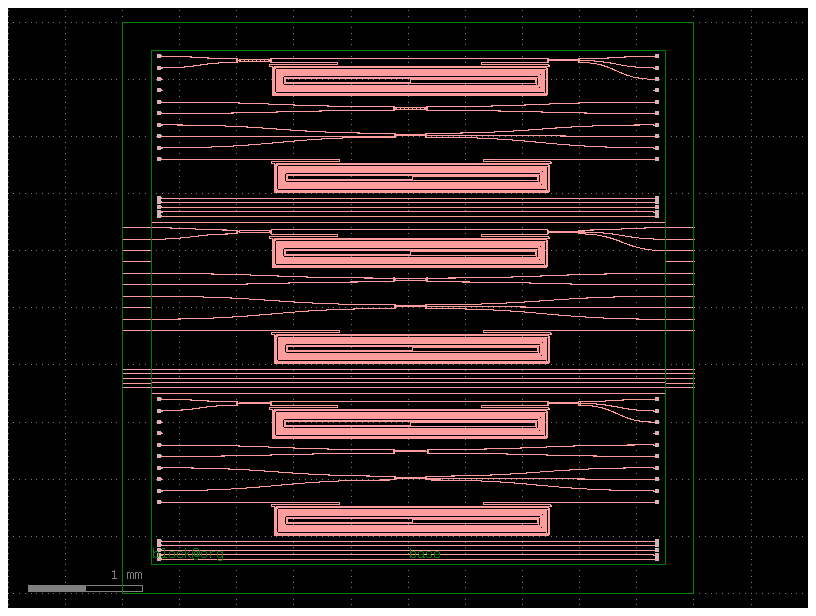

In [ ]:
main = gf.Component()
dieW = 5000
border = 250
interior = dieW - 2*border
length_mmi_95_top = 262.9723
length_mmi_33_top = 242.4723

die_ref = main << cells.die(dieW=dieW, border=border, layer_box="FLOORPLAN")
gc = gf.components.grating_coupler_elliptical(layer_slab="SLAB")
waveguide = gf.components.straight(interior - 200)
wvg_lat = gf.components.straight(border)
waveguides_test = [main << gf.components.array(component=(gf.components.straight(interior) if i == 1 else waveguide), columns=1, rows=5, row_pitch=40) for i in range(3)]
gc_top = [main << gf.components.array(component=gc, columns=1, rows=10, row_pitch=100) for _ in range(4)]
gc_down = [main << gf.components.array(component=gc, columns=1, rows=5, row_pitch=40) for _ in range(4)]
spiral_test = [main << cells.spiral_delays_test() for _ in range(3)]
mmi95_test = [main << cells.mmi_2x2_test(length_mmi_2x2=length_mmi_95_top + (3 if i == 2 else 0)) for i in range(3)]
mmi33_test = [main << cells.mmi_3x3_test(length_mmi_3x3=length_mmi_33_top + (3 if i == 2 else 0)) for i in range(3)]
wvl_tracker_ref = [main << cells.wvl_tracker(length_mmi_2x2=length_mmi_95_top + (3 if i == 2 else 0), length_mmi_3x3=length_mmi_33_top + (3 if i == 2 else 0)) for i in range(3)]
lateral_waveguides_top = [main << gf.components.array(component=wvg_lat, columns=1, rows=10, row_pitch=100) for _ in range(2)]
lateral_waveguides_down = [main << gf.components.array(component=wvg_lat, columns=1, rows=5, row_pitch=40) for _ in range(2)]

trench = [main << gf.components.straight(interior) for _ in range(2)]


# referencias para posicionar los ctos

trench[0].dmovex(die_ref["block@org"].dx).dmovey(die_ref["block@org"].dy + 2*interior/3)
trench[1].dmovex(die_ref["block@org"].dx).dmovey(die_ref["block@org"].dy + interior/3)


# posiciones comunes: top, middle, bottom

y_wvl = [die_ref["block@org"].dy + interior - 70, trench[0]["o1"].dy - 70, trench[1]["o1"].dy - 70]
y_spiral = [trench[0]["o1"].dy + 550, trench[1]["o1"].dy + 550,die_ref["base"].dy + 550]
x_waveguides = [die_ref["block@org"].dx + 100, die_ref["block@org"].dx,die_ref["block@org"].dx + 100]
y_waveguides = [trench[0].dy + 50, trench[1].dy + 50, die_ref["base"].dy + 50]

for i in range(3):
    wvl_tracker_ref[i].dmovex(die_ref["block@org"].dx + interior/6).dmovey(y_wvl[i])
    spiral_test[i].dmovex(die_ref["block@org"].dx + interior/4.2).dmovey(y_spiral[i])
    mmi95_test[i].dmovex(die_ref["block@org"].dx + interior/2 - length_mmi_95_top/2).dmovey(wvl_tracker_ref[i]["o1"].dy - 320 - 100)
    mmi33_test[i].dmovex(die_ref["block@org"].dx + interior/2 - length_mmi_33_top/2).dmovey(mmi95_test[i]["o2"].dy - 200)
    waveguides_test[i].dmovex(x_waveguides[i]).dmovey(y_waveguides[i])


# top
gc_top[0].mirror_x()
gc_top[0].dmovex(die_ref["block@org"].dx + 100).dmovey(trench[0]["o1"].dy + 550)
gc_top[1].dmovex(die_ref["block@org"].dx + interior - 100).dmovey(trench[0]["o1"].dy + 550)
gc_down[0].mirror_x()
gc_down[0].dmovex(waveguides_test[0]["o1_1_1"].dx).dmovey(waveguides_test[0]["o1_1_1"].dy)
gc_down[1].dmovex(waveguides_test[0]["o2_1_1"].dx).dmovey(waveguides_test[0]["o1_1_1"].dy)


# middle
lateral_waveguides_top[0].dmovey(trench[1]["o1"].dy + 550)
lateral_waveguides_top[1].dmovex(interior + border).dmovey(trench[1]["o1"].dy + 550)
lateral_waveguides_down[0].dmovey(waveguides_test[1]["o1_1_1"].dy)
lateral_waveguides_down[1].dmovex(interior + border).dmovey(waveguides_test[1]["o1_1_1"].dy)

# bottom
gc_top[2].mirror_x()
gc_top[2].dmovex(die_ref["block@org"].dx + 100).dmovey(die_ref["base"].dy + 550)
gc_top[3].dmovex(die_ref["block@org"].dx + interior - 100).dmovey(die_ref["base"].dy + 550)
gc_down[2].mirror_x()
gc_down[2].dmovex(waveguides_test[2]["o1_1_1"].dx).dmovey(waveguides_test[2]["o1_1_1"].dy)
gc_down[3].dmovex(waveguides_test[2]["o2_1_1"].dx).dmovey(waveguides_test[2]["o1_1_1"].dy)

#top
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_10_1'], port2=wvl_tracker_ref[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o3'], port2=gc_top[1]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_9_1'], port2=wvl_tracker_ref[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o4'], port2=gc_top[1]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[0]['o5'], port2=gc_top[1]['o1_8_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_6_1'], port2=mmi95_test[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[0]['o3'], port2=gc_top[1]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_5_1'], port2=mmi95_test[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[0]['o4'], port2=gc_top[1]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_4_1'], port2=mmi33_test[0]['o1'], cross_section="strip")
#gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_3_1'], port2=mmi33_test[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o3'], port2=gc_top[1]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o4'], port2=gc_top[1]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_2_1'], port2=mmi33_test[0]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[0]['o5'], port2=gc_top[1]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[0]['o1_1_1'], port2=spiral_test[0]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=spiral_test[0]['o2'], port2=gc_top[1]['o1_1_1'], cross_section="strip")

#middle
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_10_1'], port2=wvl_tracker_ref[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o3'], port2=lateral_waveguides_top[1]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_9_1'], port2=wvl_tracker_ref[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o4'], port2=lateral_waveguides_top[1]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=wvl_tracker_ref[1]['o5'], port2=lateral_waveguides_top[1]['o1_8_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_6_1'], port2=mmi95_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi95_test[1]['o3'], port2=lateral_waveguides_top[1]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_5_1'], port2=mmi95_test[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi95_test[1]['o4'], port2=lateral_waveguides_top[1]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_4_1'], port2=mmi33_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o3'], port2=lateral_waveguides_top[1]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o4'], port2=lateral_waveguides_top[1]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_2_1'], port2=mmi33_test[1]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=mmi33_test[1]['o5'], port2=lateral_waveguides_top[1]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main, port1=lateral_waveguides_top[0]['o2_1_1'], port2=spiral_test[1]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main, port1=spiral_test[1]['o2'], port2=lateral_waveguides_top[1]['o1_1_1'], cross_section="strip")

#bottom
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_10_1'], port2=wvl_tracker_ref[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o3'], port2=gc_top[3]['o1_10_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_9_1'], port2=wvl_tracker_ref[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o4'], port2=gc_top[3]['o1_9_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=wvl_tracker_ref[2]['o5'], port2=gc_top[3]['o1_8_1'], cross_section="strip")


gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_6_1'], port2=mmi95_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[2]['o3'], port2=gc_top[3]['o1_6_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_5_1'], port2=mmi95_test[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi95_test[2]['o4'], port2=gc_top[3]['o1_5_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_4_1'], port2=mmi33_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o3'], port2=gc_top[3]['o1_4_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o4'], port2=gc_top[3]['o1_3_1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_2_1'], port2=mmi33_test[2]['o2'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=mmi33_test[2]['o5'], port2=gc_top[3]['o1_2_1'], cross_section="strip")

gf.routing.route_single_sbend(main,port1=gc_top[2]['o1_1_1'], port2=spiral_test[2]['o1'], cross_section="strip")
gf.routing.route_single_sbend(main,port1=spiral_test[2]['o2'], port2=gc_top[3]['o1_1_1'], cross_section="strip")

main.plot()
main.show()

## Componentes

En esta sección se ha preparado una visualización de los dispositivos utilizados para la creación del circuito para poder examinarlos con mayor facilidad. 

### MMI 3x3

2026-05-12 15:37:57.406 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


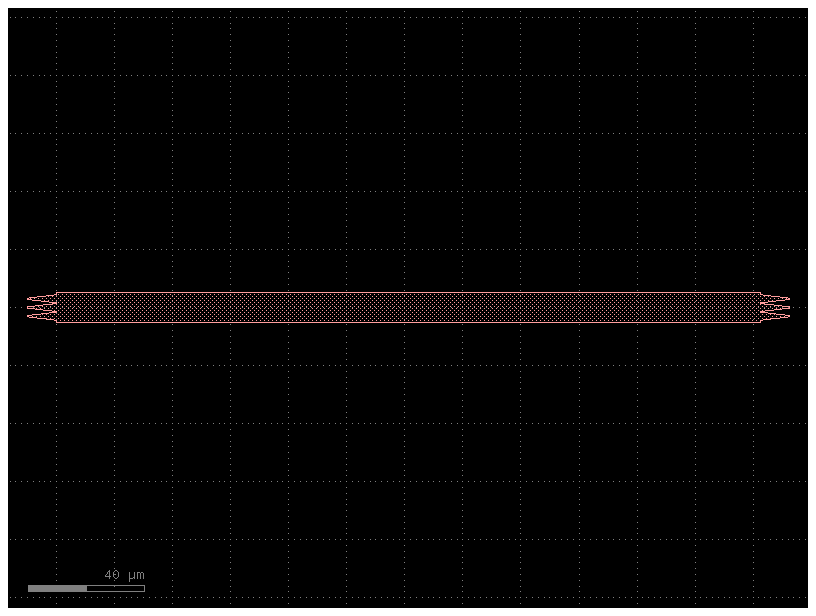

In [ ]:
c = cells.mmi3x3(width= 0.45, width_taper=2.8, length_taper= 10.0, length_mmi = 242.4723, width_mmi= 10, gap_mmi = 0.2)

c.show()
c.plot()

### Espiral

In [4]:
rad = 10
N_spr = 10
dy_spr = 10
target_length = 56000  # in microns 
#target_length = 56032.624

dx_length_spiral = cells.define_spiral_length(delay_length=target_length,
                                        N_spr=N_spr, #N_spr: order-number of loops (0,1,...)
                                        radius=rad, 
                                        d_SPR=10, #d_SPR: waveguide separation
                                        dy_SPR=dy_spr,#dy_SPR: spiral straight extent in y
                                        )

spiral = cells.spiral_upv(
        radius=rad,
        N_spr=N_spr,
        d_SPR = 10,
        dy_SPR = dy_spr,
        dx_SPR = dx_length_spiral,
        layer="strip",
        )
print('Spiral length', spiral.info["length"])

Defining spiral length for delay: 56000
Spiral length set to: 2152.431640625
Spiral length 55999.889


### Wavelength tracker

2026-05-12 16:38:59.867 | INFO     | kfactory.kcell:show:3995 - klive v0.4.1: Reloaded file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/1582829281.oas'
Longitud total del dispositivo: 2977.8766 um
Longitud del brazo corto: 2432.4320000000002 um


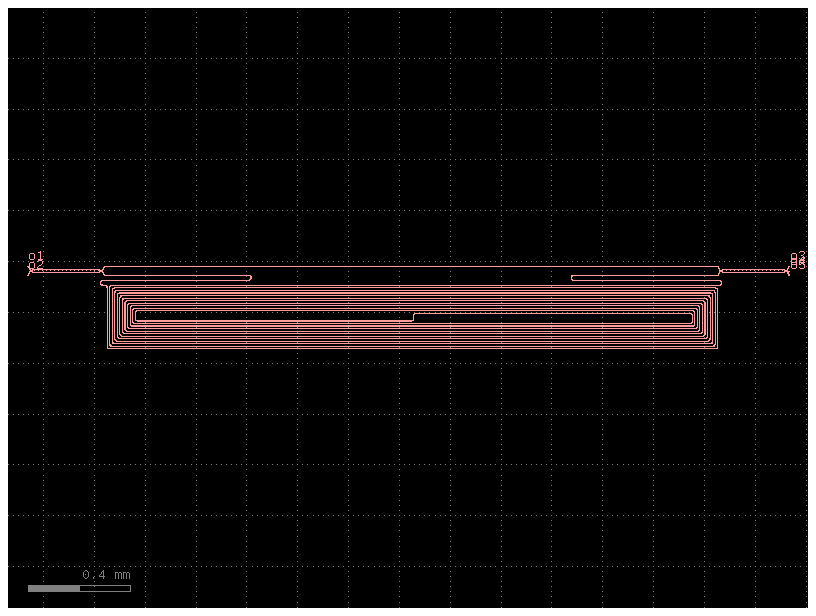

In [2]:
c = gf.Component()
circuito = c << cells.wvl_tracker()
cto_info = cells.wvl_tracker()
c.add_ports(circuito)
c.draw_ports()
c.plot()
c.show()
print(f'Longitud total del dispositivo: {cto_info.info["total_length_device"]} um')
print(f'Longitud del brazo corto: {cto_info.info["length_short_arm"]} um')
h_bends_33 = cto_info.info["h_bends_33"]

### Estructuras de test

2026-05-15 11:52:17.870 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/2464937446.oas'


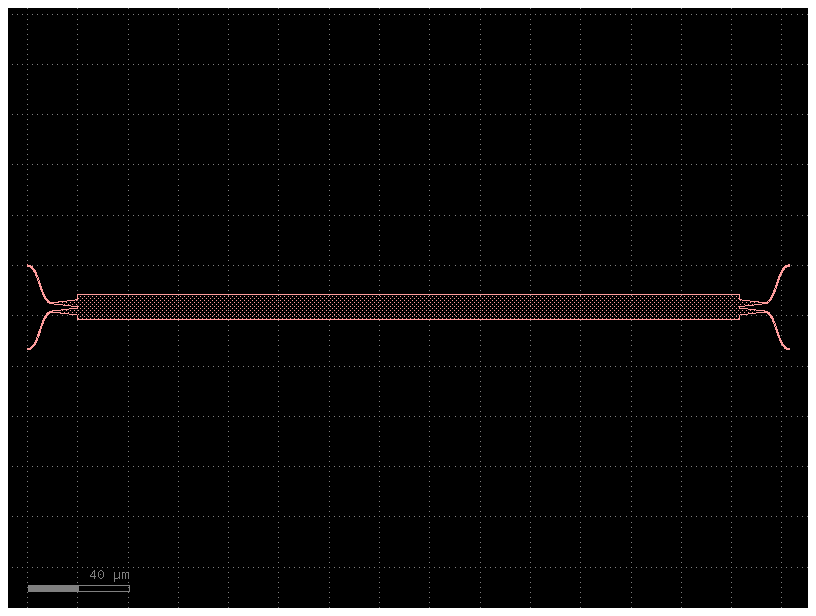

In [2]:

test= cells.mmi_2x2_test()
test.plot()
test.show()



2026-05-15 11:54:30.462 | INFO     | kfactory.kcell:show:3979 - klive v0.4.1: Opened file '/home/maria_romero/pic-upv-lab5-finalproject/build/oas/3472214404.oas'


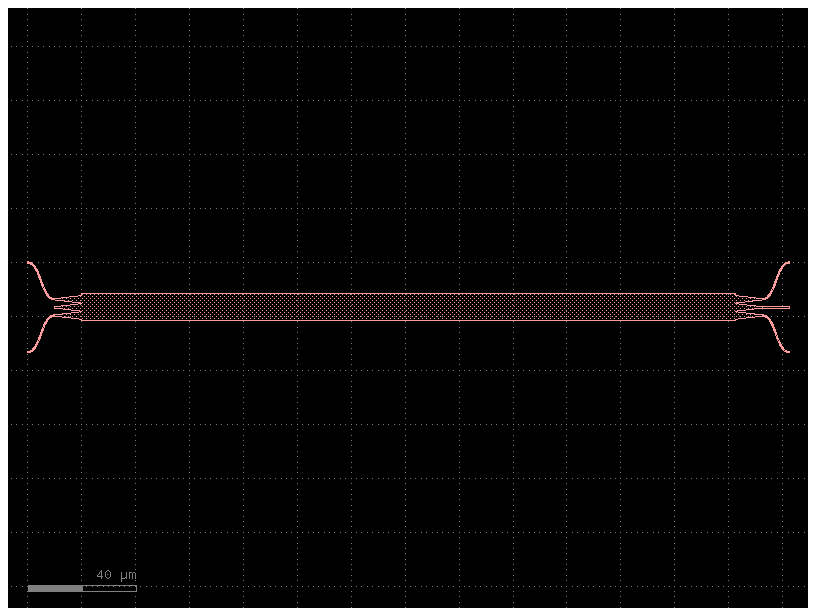

In [3]:

test = cells.mmi_3x3_test()
test.plot()
test.show()
    

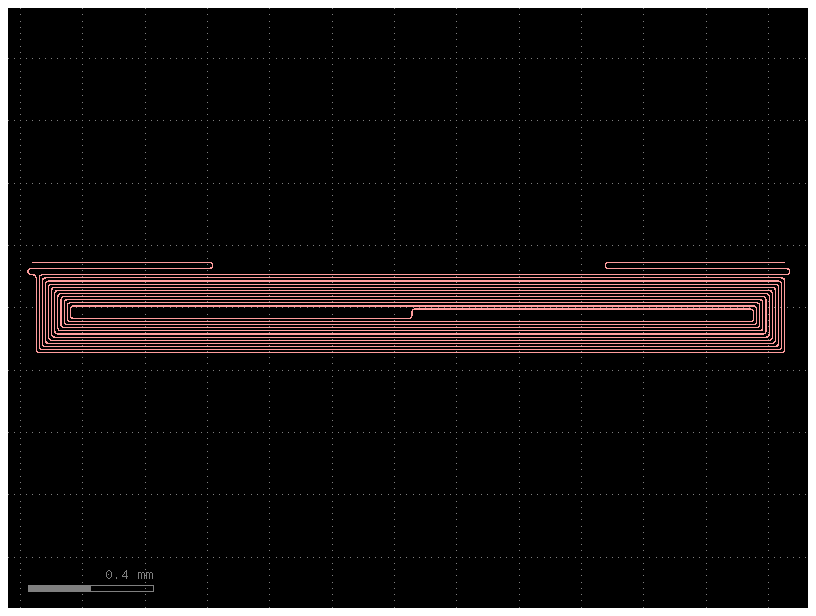

In [ ]:

test = cells.spiral_delays_test()
test.plot()
